# PUC-Rio — Departamento de Engenharia Elétrica
# Aula Prática: Séries Temporais com MLP


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

# Estilo global dos gráficos
plt.rcParams.update({
  'figure.dpi': 110,
  'axes.spines.top': False,
  'axes.spines.right': False,
  'axes.grid': True,
  'grid.alpha': 0.3,
})

### Dados da aula

Usaremos o dataset **Air Quality (UCI)** — medições horárias de poluentes e temperatura em uma cidade italiana.
Nossa variável alvo será `CO(GT)` (concentração de monóxido de carbono).
Features auxiliares: `PT08.S1(CO)` (sensor de CO), `T` (temperatura), `RH` (umidade relativa).

In [25]:
import io, zipfile, urllib.request

url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
    '00360/AirQualityUCI.zip')
resp = urllib.request.urlopen(url)
z  = zipfile.ZipFile(io.BytesIO(resp.read()))
df  = pd.read_csv(z.open('AirQualityUCI.csv'),
          sep=';', decimal=',',
          parse_dates={'datetime': ['Date','Time']},
          dayfirst=True)

TARGET_COL  = 'CO(GT)'
FEATURE_COLS = ['CO(GT)', 'PT08.S1(CO)', 'T', 'RH']

df.replace(-200, np.nan, inplace=True)
df.dropna(subset=FEATURE_COLS, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape: {df.shape}')
df[FEATURE_COLS].head()

Shape: (7344, 16)


,CO(GT),PT08.S1(CO),T,RH
0,2.6,1360.0,13.6,48.9
1,2.0,1292.0,13.3,47.7
2,2.2,1402.0,11.9,54.0
3,2.2,1376.0,11.0,60.0
4,1.6,1272.0,11.2,59.6


---
## Bloco 1 — O que é uma Série Temporal?

Uma **série temporal** é uma sequência de observações ordenadas no tempo.
A ordem importa — embaralhar os dados destrói a estrutura.

Três propriedades fundamentais que observamos antes de modelar:

| Propriedade | O que é | Como detectar visualmente |
|-------------|---------|---------------------------|
| **Tendência** | Crescimento ou decrescimento de longo prazo | Média móvel inclinada |
| **Sazonalidade** | Padrão repetitivo com período fixo | Picos/vales regulares |
| **Estacionariedade** | Média e variância constantes no tempo | Média móvel horizontal, std estável |

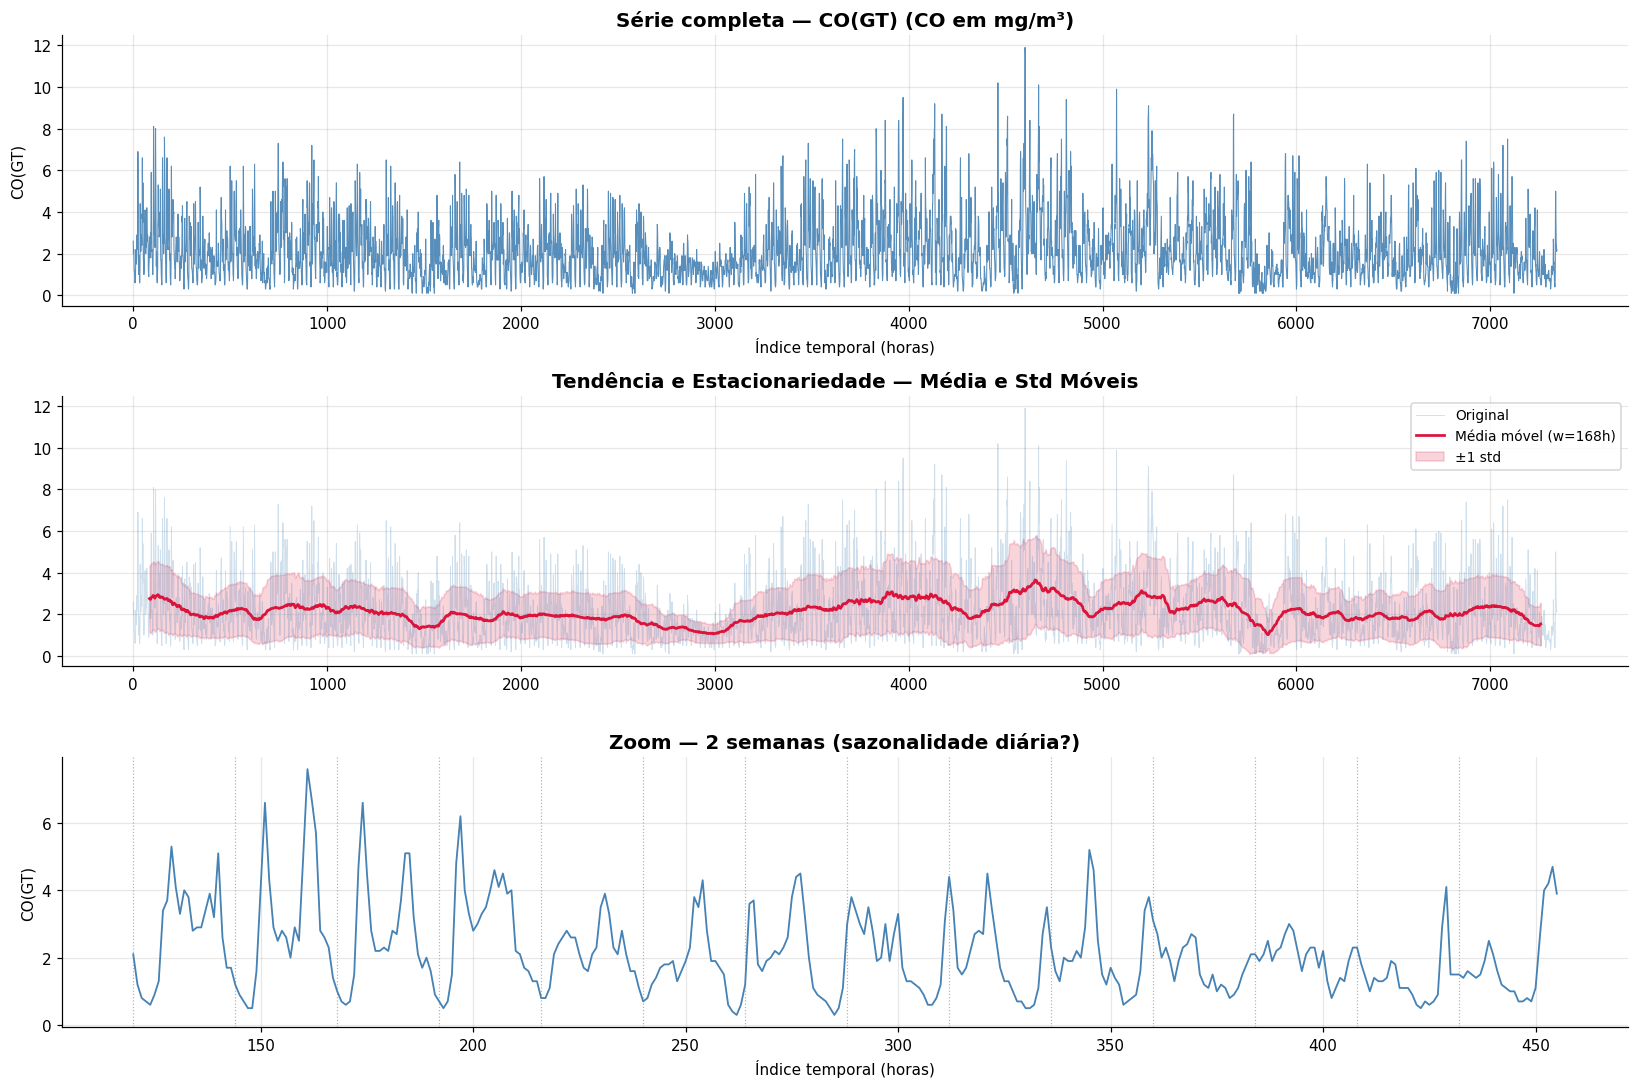

In [26]:
# ── Visualização completa da série ──────────────────────────────────────────
series = df[TARGET_COL].values

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1. Série completa
axes[0].plot(series, color='steelblue', linewidth=0.7, alpha=0.9)
axes[0].set_title(f'Série completa — {TARGET_COL} (CO em mg/m³)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Índice temporal (horas)')
axes[0].set_ylabel('CO(GT)')

# 2. Média e desvio móveis — detecta tendência e estacionariedade
W = 24 * 7  # janela de 1 semana
roll_m = pd.Series(series).rolling(W, center=True).mean()
roll_s = pd.Series(series).rolling(W, center=True).std()
axes[1].plot(series, alpha=0.25, linewidth=0.6, color='steelblue', label='Original')
axes[1].plot(roll_m, color='crimson', linewidth=1.8, label=f'Média móvel (w={W}h)')
axes[1].fill_between(range(len(series)),
           roll_m - roll_s, roll_m + roll_s,
           alpha=0.18, color='crimson', label='±1 std')
axes[1].set_title('Tendência e Estacionariedade — Média e Std Móveis', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

# 3. Zoom em 2 semanas — detecta padrão diário (sazonalidade)
zoom_start, zoom_end = 24*5, 24*5 + 24*14
t_zoom = np.arange(zoom_start, zoom_end)
axes[2].plot(t_zoom, series[zoom_start:zoom_end], color='steelblue', linewidth=1.2)
# Marca meia-noite de cada dia
for d in range(14):
  midnight = zoom_start + d * 24
  axes[2].axvline(midnight, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
axes[2].set_title('Zoom — 2 semanas (sazonalidade diária?)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Índice temporal (horas)')
axes[2].set_ylabel('CO(GT)')

plt.tight_layout()
plt.show()

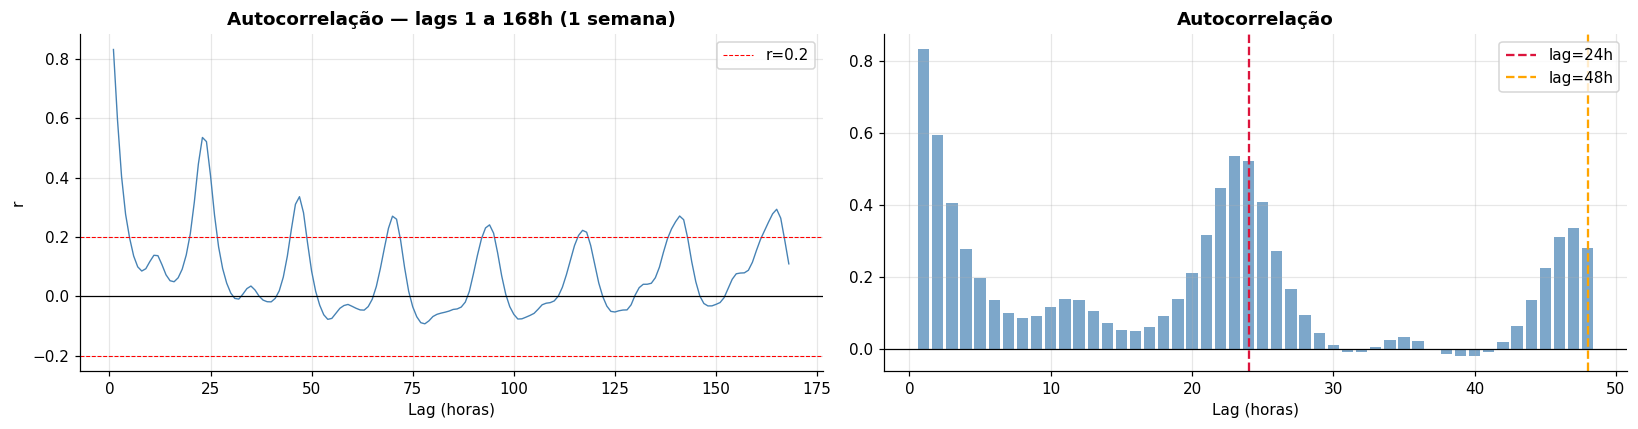

Autocorrelações em lags-chave:
 lag=   1h → r = +0.8315
 lag=   2h → r = +0.5947
 lag=   6h → r = +0.1362
 lag=  12h → r = +0.1373
 lag=  24h → r = +0.5213
 lag=  48h → r = +0.2818
 lag= 168h → r = +0.1098


In [27]:
# ── Autocorrelação — revela memória e periodicidade ──────────────────────────
s = pd.Series(series)
max_lag = 24 * 7  # até 1 semana
lags  = range(1, max_lag + 1)
autocorr = [s.autocorr(lag=k) for k in lags]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Autocorrelação completa
axes[0].plot(lags, autocorr, color='steelblue', linewidth=0.9)
axes[0].axhline(0,  color='black', linewidth=0.8)
axes[0].axhline(0.2, color='red',  linewidth=0.7, linestyle='--', label='r=0.2')
axes[0].axhline(-0.2, color='red',  linewidth=0.7, linestyle='--')
axes[0].set_title('Autocorrelação — lags 1 a 168h (1 semana)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (horas)'); axes[0].set_ylabel('r')
axes[0].legend()

# Zoom nos primeiros 48h — mostra o ciclo diário de 24h
axes[1].bar(range(1, 49), autocorr[:48], color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(24, color='crimson', linewidth=1.5, linestyle='--', label='lag=24h')
axes[1].axvline(48, color='orange', linewidth=1.5, linestyle='--', label='lag=48h')
axes[1].set_title('Autocorrelação', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (horas)'); axes[1].legend()

plt.tight_layout()
plt.show()

print('Autocorrelações em lags-chave:')
for lag in [1, 2, 6, 12, 24, 48, 168]:
  print(f' lag={lag:4d}h → r = {s.autocorr(lag):+.4f}')

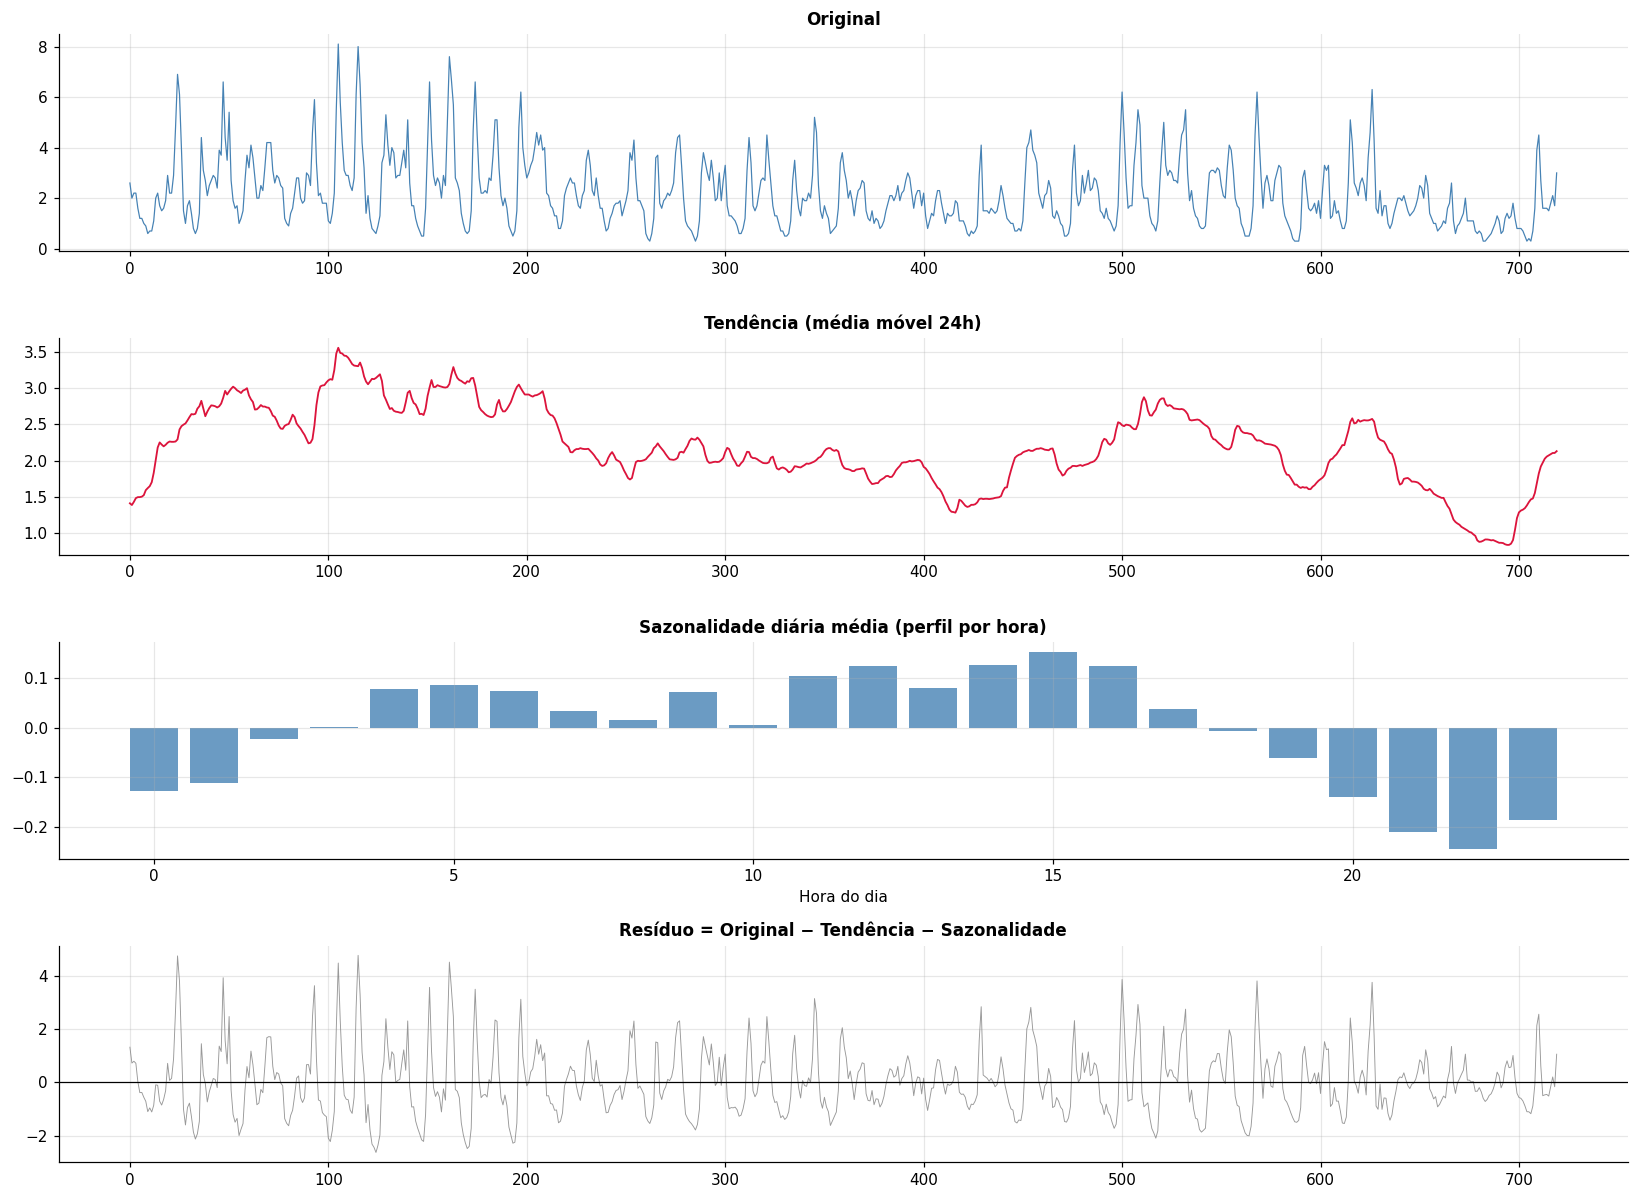

Std original : 1.4364
Std resíduo  : 1.1904
Variância explicada: 31.3%


In [28]:
# ── Decomposição manual — tendência, sazonalidade, resíduo ──────────────────
# Tendência: média móvel centralizada com janela de 24h
trend   = pd.Series(series).rolling(24, center=True, min_periods=1).mean().values
detrended = series - trend

# Sazonalidade: média por hora do dia
hour_of_day = np.tile(np.arange(24), len(series)//24 + 1)[:len(series)]
seasonal  = np.array([detrended[hour_of_day == h].mean() for h in range(24)])
seasonal_full = np.array([seasonal[h] for h in hour_of_day])
residual  = series - trend - seasonal_full

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=False)
N_show = 24 * 30  # 30 dias

axes[0].plot(series[:N_show],      color='steelblue', linewidth=0.8)
axes[0].set_title('Original',      fontsize=11, fontweight='bold')

axes[1].plot(trend[:N_show],      color='crimson', linewidth=1.2)
axes[1].set_title('Tendência (média móvel 24h)', fontsize=11, fontweight='bold')

axes[2].bar(range(24), seasonal,    color='steelblue', alpha=0.8)
axes[2].set_title('Sazonalidade diária média (perfil por hora)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Hora do dia')

axes[3].plot(residual[:N_show],     color='gray', linewidth=0.6, alpha=0.8)
axes[3].axhline(0, color='black', linewidth=0.8)
axes[3].set_title('Resíduo = Original − Tendência − Sazonalidade', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Std original : {series.std():.4f}')
print(f'Std resíduo  : {residual.std():.4f}')
print(f'Variância explicada: {(1 - residual.var()/series.var())*100:.1f}%')

> 💡 **Nota:** Removemos tendência + sazonalidade diária e ainda sobra bastante variância no resíduo — o MLP precisará aprender o que resta. A boa notícia é que ele pode fazer isso implicitamente se a janela for grande o suficiente.

---
## Bloco 2 — Transformação Tabular e Janela Deslizante

O MLP não entende sequências — ele recebe um **vetor fixo** e produz uma saída.
Para usar uma série temporal como entrada, precisamos convertê-la em um formato tabular.

A ideia central é a **janela deslizante** (*sliding window*):

```
Série:  [y₁, y₂, y₃, y₄, y₅, y₆, y₇, ...]

Janela W=3, horizon=1:

 X[0] = [y₁, y₂, y₃] → y[0] = y₄
 X[1] = [y₂, y₃, y₄] → y[1] = y₅
 X[2] = [y₃, y₄, y₅] → y[2] = y₆
 ...
```

Cada linha de X é uma **amostra** para o MLP.

In [29]:
# ── Demonstração visual da janela deslizante ─────────────────────────────────
demo_series = np.array([2.1, 3.4, 2.8, 4.0, 3.2, 5.1, 4.3, 3.9, 5.5, 4.8])
W_demo   = 3

print(f'Série de demonstração: {demo_series}')
print(f'WINDOW_SIZE = {W_demo}\n')
print(f'{"X (entrada)":35s} → y (alvo)')
print('-' * 55)

rows_X, rows_y = [], []
for i in range(len(demo_series) - W_demo):
  x_row = demo_series[i : i + W_demo]
  y_val = demo_series[i + W_demo]
  rows_X.append(x_row)
  rows_y.append(y_val)
  label = f'X[{i}] = {x_row}'
  print(f'{label:35s} → y[{i}] = {y_val}')

X_demo = np.array(rows_X)
y_demo = np.array(rows_y)
print(f'\nResultado: X.shape={X_demo.shape} y.shape={y_demo.shape}')

Série de demonstração: [2.1 3.4 2.8 4.  3.2 5.1 4.3 3.9 5.5 4.8]
WINDOW_SIZE = 3

X (entrada)                         → y (alvo)
-------------------------------------------------------
X[0] = [2.1 3.4 2.8]                → y[0] = 4.0
X[1] = [3.4 2.8 4. ]                → y[1] = 3.2
X[2] = [2.8 4.  3.2]                → y[2] = 5.1
X[3] = [4.  3.2 5.1]                → y[3] = 4.3
X[4] = [3.2 5.1 4.3]                → y[4] = 3.9
X[5] = [5.1 4.3 3.9]                → y[5] = 5.5
X[6] = [4.3 3.9 5.5]                → y[6] = 4.8

Resultado: X.shape=(7, 3) y.shape=(7,)


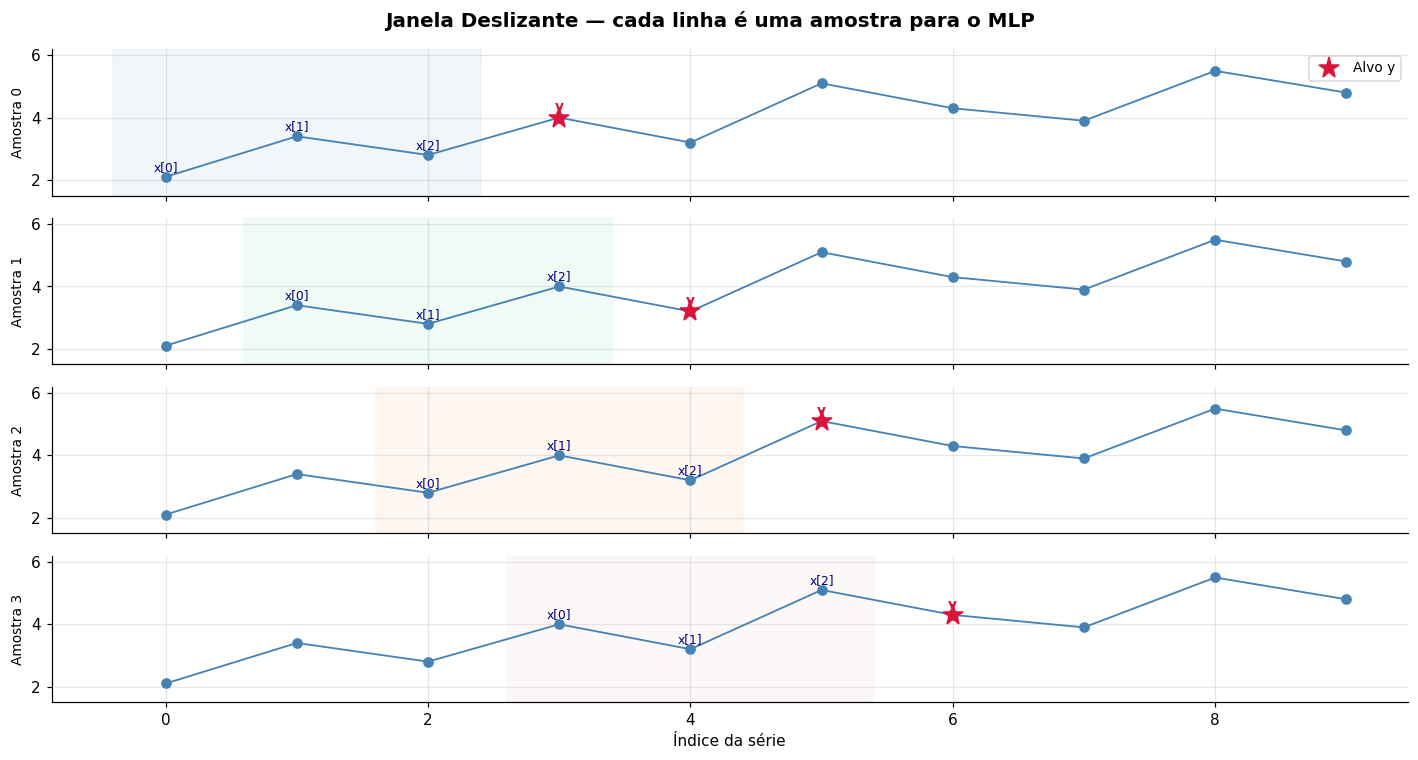

In [30]:
# ── Visualização animada (estática) da janela deslizando ─────────────────────
colors_bg = ['#d4e6f1', '#d5f5e3', '#fde8d8', '#f9ebea']
n_show   = 4

fig, axes = plt.subplots(n_show, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Janela Deslizante — cada linha é uma amostra para o MLP',
       fontsize=13, fontweight='bold')

for i, ax in enumerate(axes):
  ax.plot(range(len(demo_series)), demo_series,
      'o-', color='steelblue', linewidth=1.2, markersize=6, zorder=3)
  # Destaca a janela
  ax.axvspan(i - 0.4, i + W_demo - 1 + 0.4,
        alpha=0.35, color=colors_bg[i], zorder=1)
  # Marca o alvo
  ax.plot(i + W_demo, demo_series[i + W_demo],
      '*', color='crimson', markersize=14, zorder=4, label='Alvo y')
  ax.set_ylabel(f'Amostra {i}', fontsize=9)
  ax.set_ylim(1.5, 6.2)
  # Rótulos
  for j in range(W_demo):
    ax.text(i + j, demo_series[i + j] + 0.2,
        f'x[{j}]', ha='center', fontsize=8, color='navy')
  ax.text(i + W_demo, demo_series[i + W_demo] + 0.2,
      'y', ha='center', fontsize=9, color='crimson', fontweight='bold')

axes[-1].set_xlabel('Índice da série')
axes[0].legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

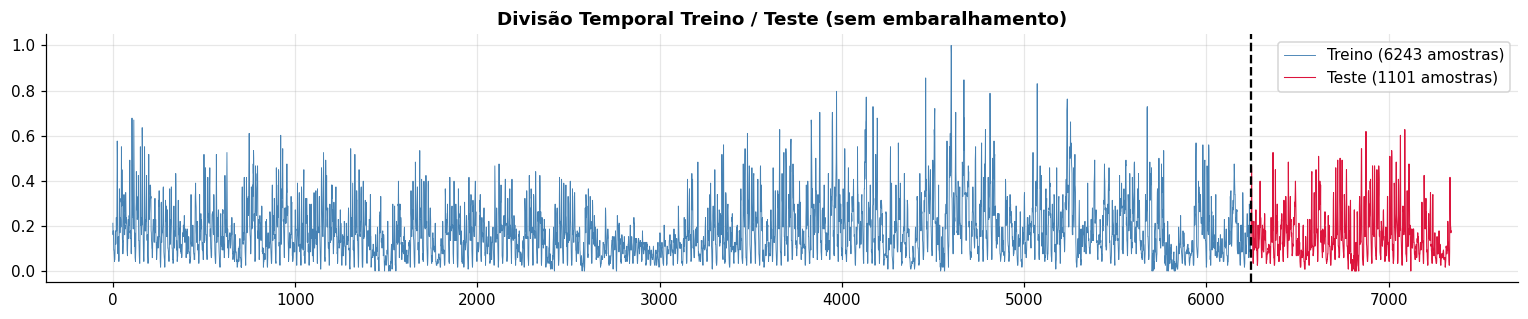

Total: 7344 | Treino: 6243 | Teste: 1101
WINDOW_SIZE=24 | HORIZON=12


In [31]:
# ── Divisão temporal treino/teste — NÃO embaralhamos ─────────────────────────
WINDOW_SIZE = 24  # 1 ciclo diário
HORIZON   = 12  # 12 horas à frente (multi-step)
TEST_SPLIT = 0.15
BATCH_SIZE = 64

n_total = len(df)
n_test = int(n_total * TEST_SPLIT)
n_train = n_total - n_test

# Normalização: fit APENAS no treino
n_features = len(FEATURE_COLS)
scaler   = MinMaxScaler()
scaler.fit(df[FEATURE_COLS].values[:n_train])

scaled = scaler.transform(df[FEATURE_COLS].values)
df_sc  = pd.DataFrame(scaled, columns=FEATURE_COLS)
target_idx = FEATURE_COLS.index(TARGET_COL)

series_sc = df_sc[TARGET_COL].values

# Visualiza a divisão
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(range(n_train), series_sc[:n_train],
    color='steelblue', linewidth=0.6, label=f'Treino ({n_train} amostras)')
ax.plot(range(n_train, n_total), series_sc[n_train:],
    color='crimson', linewidth=0.7, label=f'Teste ({n_test} amostras)')
ax.axvline(n_train, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Divisão Temporal Treino / Teste (sem embaralhamento)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total: {n_total} | Treino: {n_train} | Teste: {n_test}')
print(f'WINDOW_SIZE={WINDOW_SIZE} | HORIZON={HORIZON}')

X_train : (6219, 24) — 6219 amostras, 24 features (= WINDOW_SIZE)
y_train : (6219,)
X_test : (1101, 24)

Exemplo X_train[0] (primeira janela):
[0.2119 0.161  0.178  0.178  0.1271 0.0932 0.0932 0.0763 0.0678 0.0424
 0.0508 0.0508 0.0847 0.161  0.178  0.1356 0.1186 0.1271 0.1525 0.2373
 0.178  0.178  0.2373 0.3983]
Target correspondente y_train[0]: 0.5763


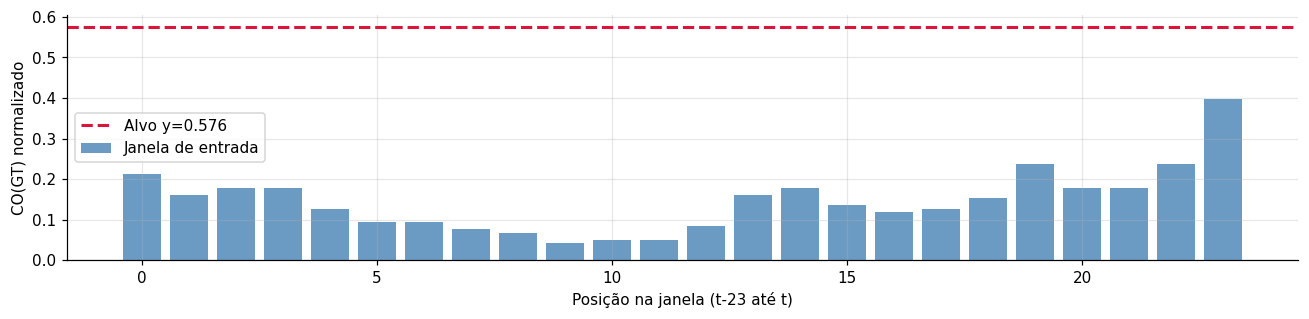

In [32]:
# ── Função de janelamento ────────────────────────────────────────────────────
def make_windows(series, window_size, horizon=1):
  """Janela deslizante para série 1-D."""
  X, y = [], []
  for i in range(len(series) - window_size - horizon + 1):
    X.append(series[i : i + window_size])
    chunk = series[i + window_size : i + window_size + horizon]
    y.append(chunk[0] if horizon == 1 else chunk)
  return np.array(X), np.array(y)


# Janelas univariadas para one-step
X_all, y_all = make_windows(series_sc, WINDOW_SIZE, horizon=1)
split = n_train - WINDOW_SIZE
X_tr, X_te = X_all[:split], X_all[split:]
y_tr, y_te = y_all[:split], y_all[split:]

print(f'X_train : {X_tr.shape} — {X_tr.shape[0]} amostras, {X_tr.shape[1]} features (= WINDOW_SIZE)')
print(f'y_train : {y_tr.shape}')
print(f'X_test : {X_te.shape}')
print()
print('Exemplo X_train[0] (primeira janela):')
print(X_tr[0].round(4))
print(f'Target correspondente y_train[0]: {y_tr[0]:.4f}')

# Visualiza o que o MLP "vê" em uma amostra
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(WINDOW_SIZE), X_tr[0], color='steelblue', alpha=0.8, label='Janela de entrada')
ax.axhline(y_tr[0], color='crimson', linewidth=2, linestyle='--', label=f'Alvo y={y_tr[0]:.3f}')
ax.set_xlabel('Posição na janela (t-23 até t)'); ax.set_ylabel('CO(GT) normalizado')
ax.legend()
plt.tight_layout()
plt.show()

---
## Bloco 3 — MLP One-Step: Treinando o Primeiro Modelo

Com os dados no formato correto, podemos treinar um MLP simples para prever **um passo à frente**.
Vamos construir o modelo, treiná-lo e entender o que as métricas nos dizem.

In [33]:
# ── Dataset, MLP e função de treino ─────────────────────────────────────────

class TSDataset(torch.utils.data.Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    y_t  = torch.tensor(y, dtype=torch.float32)
    self.y = y_t.unsqueeze(1) if y_t.dim() == 1 else y_t
  def __getitem__(self, i):
    return self.X[i], self.y[i]
  def __len__(self):
    return len(self.X)


class MLP(nn.Module):
  _acts = {'relu': nn.ReLU, 'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh}
  def __init__(self, n_input, hidden_layers, n_output=1, activation='relu'):
    super().__init__()
    act = self._acts[activation]
    layers, d = [], n_input
    for h in hidden_layers:
      layers += [nn.Linear(d, h), act()]; d = h
    layers.append(nn.Linear(d, n_output))
    self.net = nn.Sequential(*layers)
  def forward(self, x): return self.net(x)


def train_model(model, loader, epochs=300, lr=1e-3, loss_fn=None, verbose=True):
  if loss_fn is None: loss_fn = nn.MSELoss()
  opt   = torch.optim.Adam(model.parameters(), lr=lr)
  history = []
  model.train()
  for ep in range(1, epochs + 1):
    ep_loss = 0
    for Xb, yb in loader:
      opt.zero_grad()
      loss = loss_fn(model(Xb), yb)
      loss.backward(); opt.step()
      ep_loss += loss.item()
    history.append(ep_loss / len(loader))
    if verbose and ep % 100 == 0:
      print(f' Época {ep:4d}/{epochs} | Perda: {history[-1]:.6f}')
  return history


def predict(model, X):
  model.eval()
  with torch.no_grad():
    return model(torch.tensor(X, dtype=torch.float32)).numpy().ravel()


def denorm_target(v):
  """Desnormaliza valores do target para a escala original."""
  tmp = np.zeros((len(v), n_features))
  tmp[:, target_idx] = v
  return scaler.inverse_transform(tmp)[:, target_idx]

In [34]:
# ── Treinamento do modelo one-step univariado ────────────────────────────────
loader_tr = DataLoader(TSDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=False)

model_1step = MLP(n_input=WINDOW_SIZE, hidden_layers=[64, 32], n_output=1, activation='relu')

print(f'Arquitetura: input={WINDOW_SIZE} → [64] → [32] → output=1')
print(f'Parâmetros totais: {sum(p.numel() for p in model_1step.parameters()):,}\n')
print('Treinando...')
hist_1step = train_model(model_1step, loader_tr, epochs=100, lr=1e-3, verbose=True)

Arquitetura: input=24 → [64] → [32] → output=1
Parâmetros totais: 3,713

Treinando...
 Época  100/100 | Perda: 0.002559


MSE = 0.3223
RMSE = 0.5677 (mesma unidade da série: mg/m³)
MAE = 0.3974
Erro relativo médio ≈ 20.6% da média da série


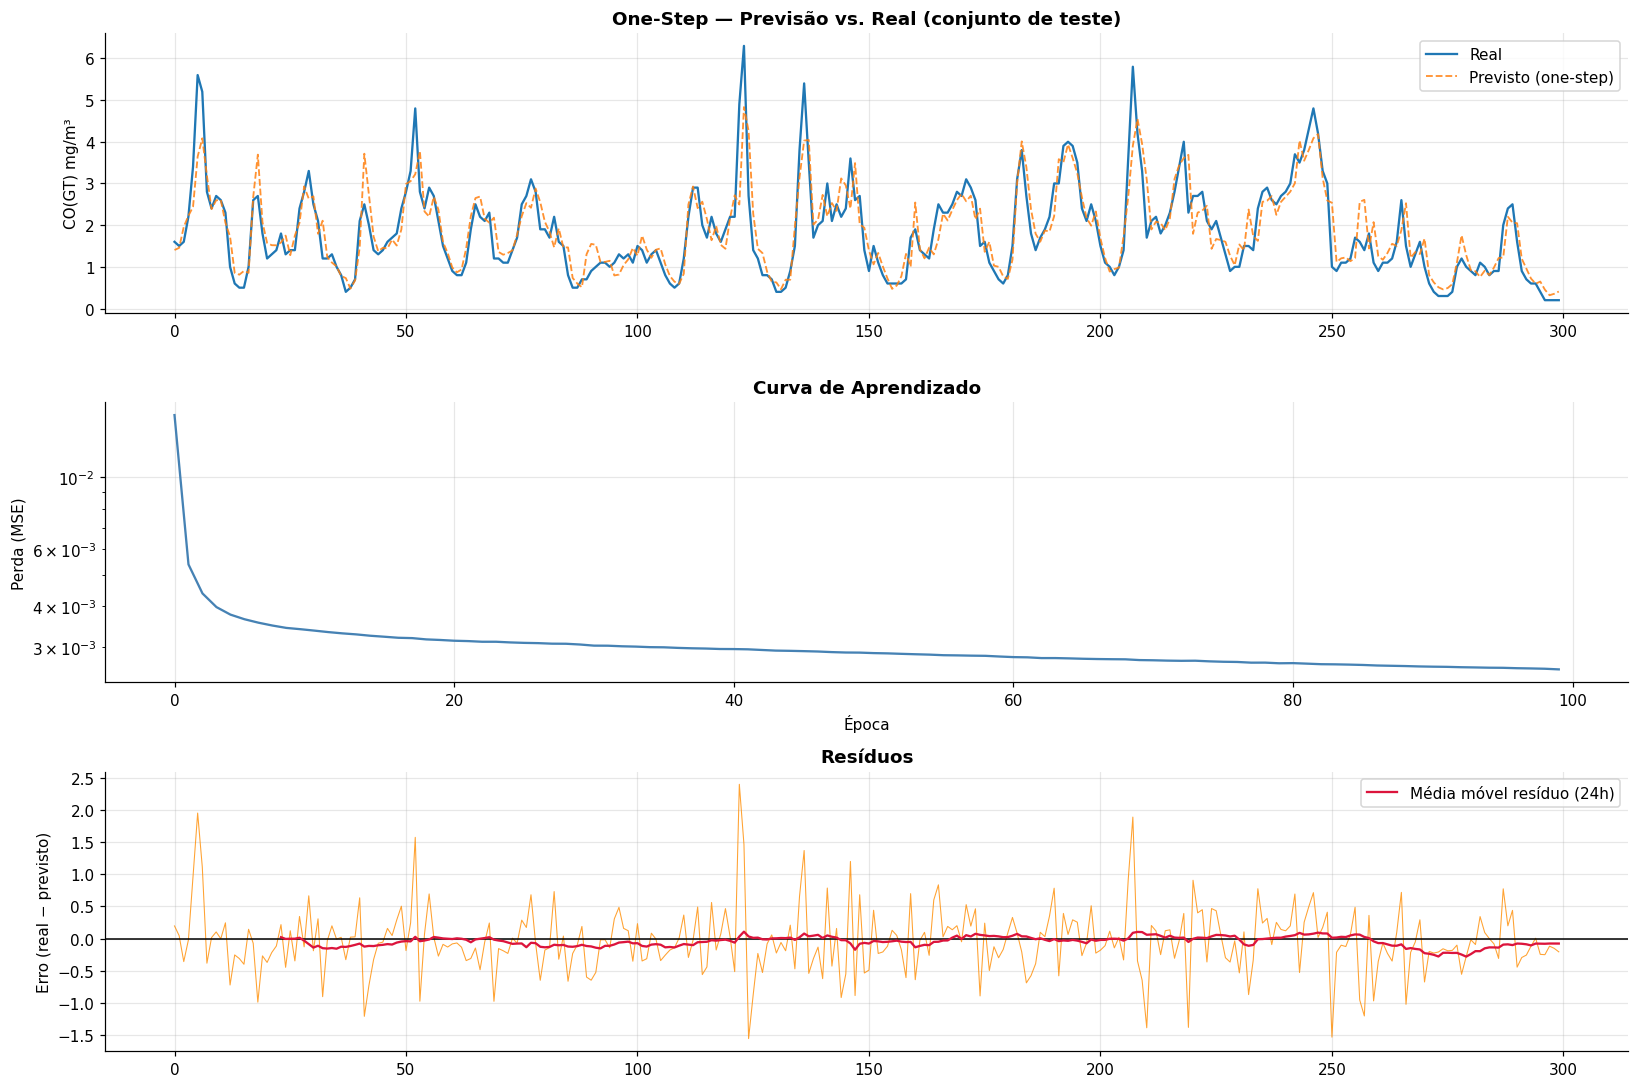

In [35]:
# ── Avaliação e visualização ─────────────────────────────────────────────────
yp_1step = predict(model_1step, X_te)

yt_orig = denorm_target(y_te)
yp_orig = denorm_target(yp_1step)
residuals_1step = yt_orig - yp_orig

mse = mean_squared_error(yt_orig, yp_orig)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yt_orig, yp_orig)

print(f'MSE = {mse:.4f}')
print(f'RMSE = {rmse:.4f} (mesma unidade da série: mg/m³)')
print(f'MAE = {mae:.4f}')
print(f'Erro relativo médio ≈ {mae / yt_orig.mean() * 100:.1f}% da média da série')

N_plot = min(300, len(yt_orig))
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Previsão vs Real
axes[0].plot(yt_orig[:N_plot], linewidth=1.5, label='Real')
axes[0].plot(yp_orig[:N_plot], linewidth=1.2, linestyle='--', alpha=0.85, label='Previsto (one-step)')
axes[0].set_title('One-Step — Previsão vs. Real (conjunto de teste)', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].set_ylabel('CO(GT) mg/m³')

# Curva de aprendizado
axes[1].plot(hist_1step, color='steelblue')
axes[1].set_title('Curva de Aprendizado', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Perda (MSE)')
axes[1].set_yscale('log')

# Resíduos
axes[2].plot(residuals_1step[:N_plot], color='darkorange', linewidth=0.7, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=1)
roll_r = pd.Series(residuals_1step[:N_plot]).rolling(24).mean()
axes[2].plot(roll_r, color='crimson', linewidth=1.5, label='Média móvel resíduo (24h)')
axes[2].set_title('Resíduos', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Erro (real − previsto)'); axes[2].legend()

plt.tight_layout()
plt.show()

Testando diferentes tamanhos de janela (univariado, one-step)...
 ws=  2 RMSE=0.05764
 ws=  6 RMSE=0.05373
 ws= 12 RMSE=0.04943
 ws= 24 RMSE=0.05146
 ws= 48 RMSE=0.05982
 ws= 72 RMSE=0.05622


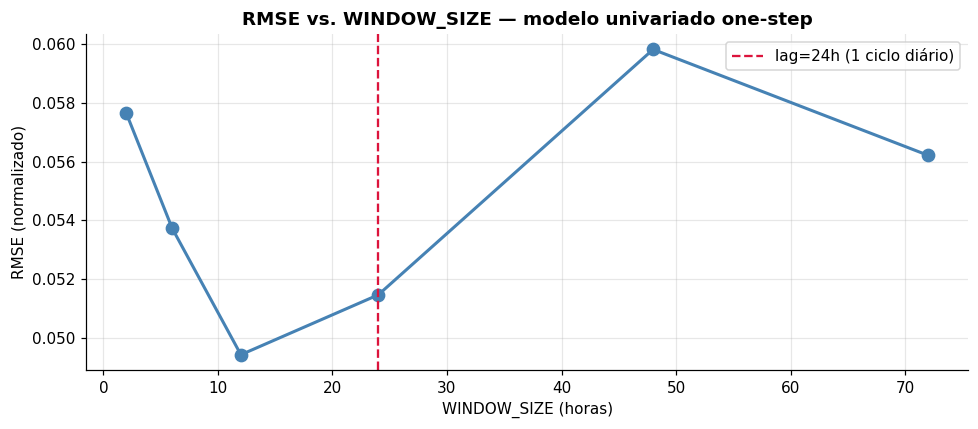

In [36]:
# ── Efeito do WINDOW_SIZE — demonstração ao vivo ─────────────────────────────
# Mostra como a janela afeta o desempenho: muito pequena vs. adequada vs. grande
window_sizes = [2, 6, 12, 24, 48, 72]
ws_results  = {}

print('Testando diferentes tamanhos de janela (univariado, one-step)...')
for ws in window_sizes:
  Xw, yw = make_windows(series_sc, ws, horizon=1)
  sp   = n_train - ws
  ld   = DataLoader(TSDataset(Xw[:sp], yw[:sp]), batch_size=BATCH_SIZE, shuffle=False)
  m   = MLP(ws, [64, 32])
  train_model(m, ld, epochs=200, verbose=False)
  yp   = predict(m, Xw[sp:])
  rmse_w = np.sqrt(mean_squared_error(yw[sp:], yp))
  ws_results[ws] = rmse_w
  print(f' ws={ws:3d} RMSE={rmse_w:.5f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(ws_results.keys()), list(ws_results.values()),
    'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(24, color='crimson', linestyle='--', linewidth=1.5, label='lag=24h (1 ciclo diário)')
ax.set_title('RMSE vs. WINDOW_SIZE — modelo univariado one-step', fontsize=12, fontweight='bold')
ax.set_xlabel('WINDOW_SIZE (horas)'); ax.set_ylabel('RMSE (normalizado)')
ax.legend()
plt.tight_layout()
plt.show()

> 💡 **Observe:** geralmente o RMSE cai até a janela capturar o ciclo relevante (24h aqui) e depois estabiliza ou sobe levemente (mais parâmetros, mesmo sinal). Isso motiva a análise de autocorrelação do Bloco 1.

---
## Bloco 4 — Previsão Multi-Step: Recursiva vs. Direta

O one-step prevê apenas **t+1**. Na prática queremos um horizonte maior.
Existem duas estratégias principais:

```
Recursiva:  treina 1 modelo one-step e alimenta as próprias previsões de volta
       [y₁,...,y₂₄] → ŷ₂₅ → [y₂,...,y₂₄,ŷ₂₅] → ŷ₂₆ → ...
       ⚠️ erros se acumulam a cada passo!

Direta:   treina 1 modelo com saída de H passos simultâneos
       [y₁,...,y₂₄] → [ŷ₂₅, ŷ₂₆, ..., ŷ₂₄₊ₕ]
       ✓ cada passo tem seu próprio conjunto de parâmetros
```

In [37]:
# ── Previsão recursiva ───────────────────────────────────────────────────────
def recursive_forecast(model, X_seed, horizon):
  """Realimenta as próprias previsões na janela."""
  model.eval()
  window, preds = X_seed.copy(), []
  with torch.no_grad():
    for _ in range(horizon):
      x_t  = torch.tensor(window, dtype=torch.float32).unsqueeze(0)
      y_hat = model(x_t).item()
      preds.append(y_hat)
      window = np.roll(window, -1)  # desliza
      window[-1] = y_hat       # insere a previsão
  return np.array(preds)


# Gera previsões recursivas para cada ponto de início no conjunto de teste
n_origins  = min(50, len(X_te) - HORIZON)  # 50 origens diferentes
rec_matrix = np.zeros((n_origins, HORIZON)) # (origens, passos)
true_matrix = np.zeros((n_origins, HORIZON))

for i in range(n_origins):
  rec_matrix[i] = recursive_forecast(model_1step, X_te[i], HORIZON)
  true_matrix[i] = y_all[split + i : split + i + HORIZON]

# RMSE médio por passo
rmse_per_step_rec = np.sqrt(np.mean((true_matrix - rec_matrix)**2, axis=0))

print('RMSE médio por passo (recursivo):')
for step, r in enumerate(rmse_per_step_rec, 1):
  bar = '█' * int(r / rmse_per_step_rec.max() * 25)
  print(f' passo {step:3d}h {bar:<25s} {r:.5f}')

RMSE médio por passo (recursivo):
 passo   1h ████████████              0.04399
 passo   2h ██████████████████        0.06327
 passo   3h ██████████████████████    0.07587
 passo   4h ████████████████████████  0.08331
 passo   5h █████████████████████████ 0.08531
 passo   6h ████████████████████████  0.08463
 passo   7h ███████████████████████   0.07858
 passo   8h ████████████████████      0.07024
 passo   9h ████████████████████      0.06917
 passo  10h ███████████████████       0.06767
 passo  11h ██████████████████        0.06425
 passo  12h █████████████████         0.05801


In [38]:
# ── Modelo direto (multi-output) ─────────────────────────────────────────────
X_ms, y_ms = make_windows(series_sc, WINDOW_SIZE, horizon=HORIZON)
X_ms_tr, X_ms_te = X_ms[:split], X_ms[split:]
y_ms_tr, y_ms_te = y_ms[:split], y_ms[split:]

loader_ms = DataLoader(TSDataset(X_ms_tr, y_ms_tr), batch_size=BATCH_SIZE, shuffle=False)

model_direct = MLP(WINDOW_SIZE, [64, 32], n_output=HORIZON)

print(f'Arquitetura direta: input={WINDOW_SIZE} → [64] → [32] → output={HORIZON}')
print('Treinando...')
train_model(model_direct, loader_ms, epochs=500, verbose=True)

Arquitetura direta: input=24 → [64] → [32] → output=12
Treinando...
 Época  100/500 | Perda: 0.007596
 Época  200/500 | Perda: 0.007185
 Época  300/500 | Perda: 0.006857
 Época  400/500 | Perda: 0.006614
 Época  500/500 | Perda: 0.006511


[0.020569580771048004,
 0.011691098290315012,
 0.010585425868250278,
 0.01004152281604213,
 0.009751288965106847,
 0.009536909066587307,
 0.009358885764543499,
 0.009211956531674202,
 0.009086191641138296,
 0.008986978374697191,
 0.008893520357467386,
 0.008823802737443119,
 0.008744872440061323,
 0.008690285353864334,
 0.008629083341196636,
 0.008585211564311567,
 0.008534721950572744,
 0.008497866202022272,
 0.008461286931545759,
 0.008427232373220732,
 0.008388471511686792,
 0.008356295507021097,
 0.008332333452666976,
 0.008306749094377406,
 0.00828506712675836,
 0.008264355501041234,
 0.008240873020793292,
 0.008218730256384315,
 0.008199813870157172,
 0.00817944311087818,
 0.008160664719572214,
 0.008143511202248117,
 0.008126113568527661,
 0.008110732662168389,
 0.008094885101427838,
 0.008081623919103866,
 0.008069958585927415,
 0.008055772492780864,
 0.008042551560460456,
 0.008029772164727732,
 0.00801908004225935,
 0.008008215775979417,
 0.007995530736052945,
 0.007984923720

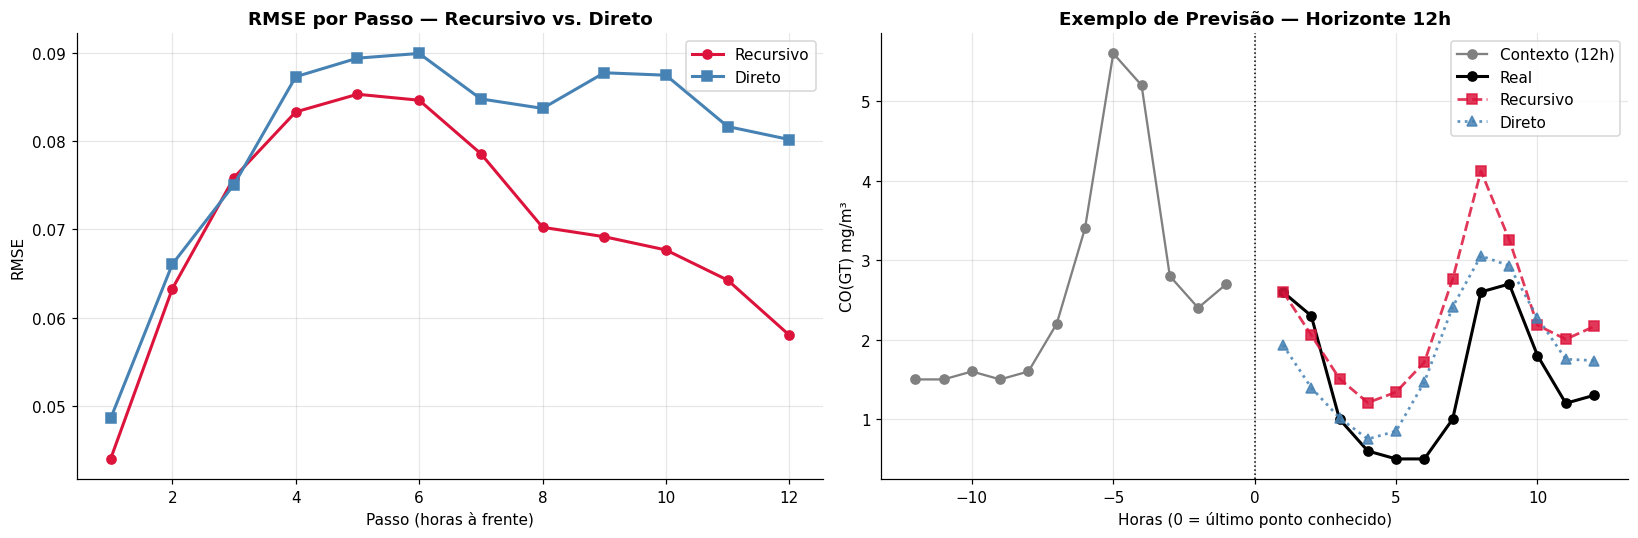

In [39]:
# ── Comparação Recursivo vs. Direto ─────────────────────────────────────────

# RMSE por passo — modelo direto
n_origins_d = min(50, len(X_ms_te) - 1)
dir_matrix  = predict(model_direct, X_ms_te[:n_origins_d]) # (n, HORIZON)
dir_matrix  = dir_matrix.reshape(n_origins_d, HORIZON)
true_ms   = y_ms_te[:n_origins_d]

rmse_per_step_dir = np.sqrt(np.mean((true_ms - dir_matrix)**2, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RMSE por passo
steps = np.arange(1, HORIZON + 1)
axes[0].plot(steps, rmse_per_step_rec, 'o-', label='Recursivo',  linewidth=2, color='crimson')
axes[0].plot(steps, rmse_per_step_dir, 's-', label='Direto',   linewidth=2, color='steelblue')
axes[0].set_title('RMSE por Passo — Recursivo vs. Direto', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passo (horas à frente)'); axes[0].set_ylabel('RMSE')
axes[0].legend()

# Visualização de uma previsão
idx_example = 10
y_true_ex = denorm_target(true_ms[idx_example])
y_rec_ex  = denorm_target(rec_matrix[idx_example])
y_dir_ex  = denorm_target(dir_matrix[idx_example])
context  = denorm_target(X_te[idx_example][-12:])  # últimas 12h da janela

t_ctx = np.arange(-12, 0)
t_fwd = np.arange(1, HORIZON + 1)

axes[1].plot(t_ctx, context,  'o-', color='gray',   linewidth=1.5, label='Contexto (12h)')
axes[1].plot(t_fwd, y_true_ex, 'o-', color='black',   linewidth=2,  label='Real')
axes[1].plot(t_fwd, y_rec_ex, 's--',color='crimson',  linewidth=1.8, label='Recursivo', alpha=0.85)
axes[1].plot(t_fwd, y_dir_ex, '^:' ,color='steelblue', linewidth=1.8, label='Direto',  alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1, linestyle=':')
axes[1].set_title(f'Exemplo de Previsão — Horizonte {HORIZON}h', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Horas (0 = último ponto conhecido)')
axes[1].set_ylabel('CO(GT) mg/m³')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Bloco 5 — Entrada Multivariada: MISO e MIMO

Até aqui usamos **só o target** como entrada (univariado). E se tivermos outras variáveis úteis?

**Duas abordagens válidas para multi-step multivariado:**

```
MISO (Multiple Input, Single Output)
 Entrada : janela de TODAS as features (W × F valores)
 Saída  : próximos H valores do TARGET (apenas)
 ✓ usa as exógenas; sem recursão; sem precisar prever as exógenas
 ✓ ideal quando só o target importa na saída

MIMO (Multiple Input, Multiple Output)
 Entrada : janela de TODAS as features (W × F valores)
 Saída  : próximos H valores de TODAS as features
 ✓ prevê tudo junto; as exógenas previstas ficam disponíveis
  se precisar avançar a janela futuramente
```

> ⚠️ **Por que não existe MISO recursivo?**
>
> Na previsão recursiva, avançamos a janela passo a passo, reinserindo a previsão.
> No caso univariado, só precisamos do próprio target — tudo bem.
> No MISO, a janela inclui features exógenas (sensor, temperatura, umidade...).
> Para avançar a janela um passo, precisaríamos do **próximo valor dessas exógenas** —
> que o modelo MISO **não previu** (ele só prevê o target).
>
> Alternativas reais para multi-step com exógenas:
> 1. **Recursivo univariado** — ignora as exógenas; usa só o target.
> 2. **MISO direto** — prevê H passos do target de uma vez; sem avançar a janela.
> 3. **MIMO** — prevê todas as features; com as exógenas previstas, a janela pode
>  ser avançada de forma consistente.


In [40]:
# ── Função de janelamento multivariado ──────────────────────────────────────
def make_windows_mv(df_sc, target_col, feature_cols,
          window_size, horizon=1, mode='MISO'):
  data  = df_sc[feature_cols].values  # (T, F)
  target = df_sc[target_col].values   # (T,)
  X, y  = [], []
  for i in range(len(data) - window_size - horizon + 1):
    X.append(data[i : i + window_size].ravel())     # (W*F,)
    if mode == 'MISO':
      chunk = target[i + window_size : i + window_size + horizon]
      y.append(chunk[0] if horizon == 1 else chunk)
    else:  # MIMO
      chunk = data[i + window_size : i + window_size + horizon]
      y.append(chunk.ravel())  # (H*F,)
  return np.array(X), np.array(y)


# Constrói janelas para cada modo
sp = n_train - WINDOW_SIZE

# MISO one-step
X_miso, y_miso = make_windows_mv(df_sc, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, 1, 'MISO')
X_miso_tr, X_miso_te = X_miso[:sp], X_miso[sp:]
y_miso_tr, y_miso_te = y_miso[:sp], y_miso[sp:]

# MIMO one-step (saída: todos os features em t+1)
X_mimo, y_mimo = make_windows_mv(df_sc, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, 1, 'MIMO')
X_mimo_tr, X_mimo_te = X_mimo[:sp], X_mimo[sp:]
y_mimo_tr, y_mimo_te = y_mimo[:sp], y_mimo[sp:]

print('Dimensões das janelas:')
print(f' Univariado X_train : {X_tr.shape}    (W={WINDOW_SIZE}, 1 feature)')
print(f' MISO    X_train : {X_miso_tr.shape}  (W={WINDOW_SIZE}, {n_features} features)')
print(f' MIMO    X_train : {X_mimo_tr.shape}  (mesma entrada)')
print(f' MISO    y_train : {y_miso_tr.shape}  (1 valor: target)')
print(f' MIMO    y_train : {y_mimo_tr.shape} (todos os {n_features} features)')

Dimensões das janelas:
 Univariado X_train : (6219, 24)    (W=24, 1 feature)
 MISO    X_train : (6219, 96)  (W=24, 4 features)
 MIMO    X_train : (6219, 96)  (mesma entrada)
 MISO    y_train : (6219,)  (1 valor: target)
 MIMO    y_train : (6219, 4) (todos os 4 features)


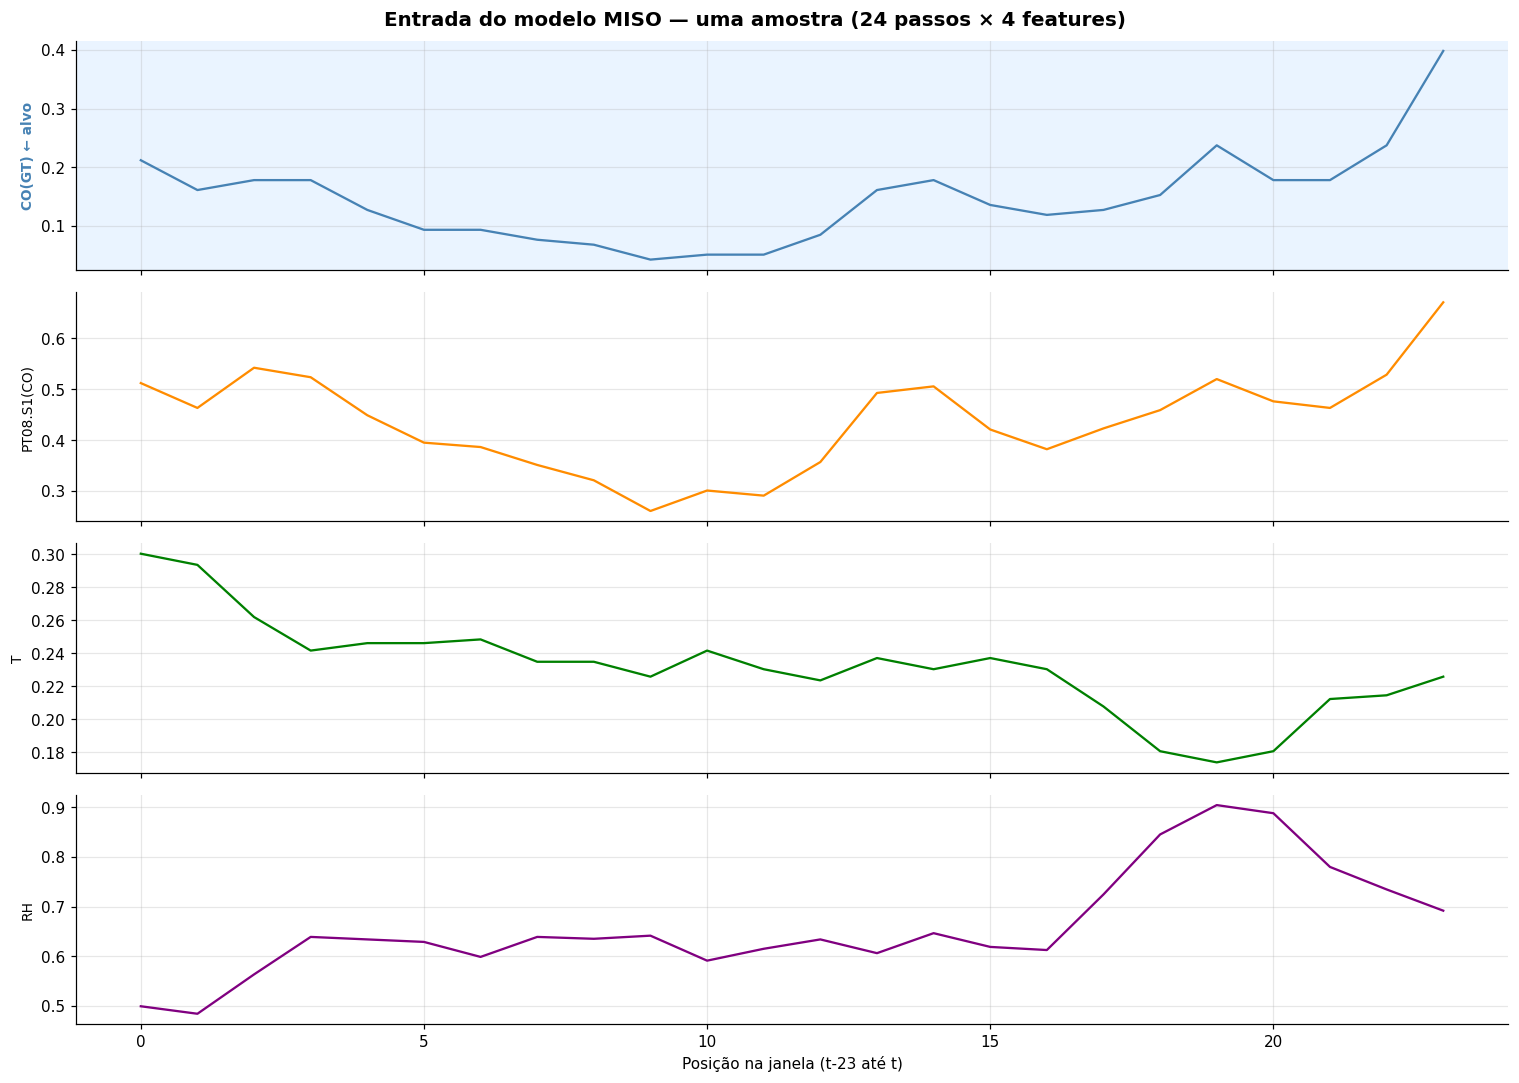

In [41]:
# ── O que o MISO "vê" vs. o univariado ──────────────────────────────────────
fig, axes = plt.subplots(n_features, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Entrada do modelo MISO — uma amostra ({WINDOW_SIZE} passos × {n_features} features)',
       fontsize=13, fontweight='bold')

sample = X_miso_tr[0].reshape(WINDOW_SIZE, n_features)
colors = ['steelblue', 'darkorange', 'green', 'purple']

for i, (feat, ax) in enumerate(zip(FEATURE_COLS, axes)):
  ax.plot(sample[:, i], color=colors[i], linewidth=1.5)
  ax.set_ylabel(feat, fontsize=9)
  if feat == TARGET_COL:
    ax.set_facecolor('#eaf4ff')
    ax.set_ylabel(f'{feat} ← alvo', fontsize=9, color='steelblue', fontweight='bold')

axes[-1].set_xlabel('Posição na janela (t-23 até t)')
plt.tight_layout()
plt.show()

In [42]:
# ── Treinamento MISO e MIMO ──────────────────────────────────────────────────
loader_miso = DataLoader(TSDataset(X_miso_tr, y_miso_tr), batch_size=BATCH_SIZE, shuffle=False)
loader_mimo = DataLoader(TSDataset(X_mimo_tr, y_mimo_tr), batch_size=BATCH_SIZE, shuffle=False)

model_miso = MLP(WINDOW_SIZE * n_features, [64, 32], n_output=1)
model_mimo = MLP(WINDOW_SIZE * n_features, [64, 32], n_output=n_features)

print(f'Parâmetros MISO: {sum(p.numel() for p in model_miso.parameters()):,}')
print(f'Parâmetros MIMO: {sum(p.numel() for p in model_mimo.parameters()):,}')

print('\n=== Treinando MISO ===')
hist_miso = train_model(model_miso, loader_miso, epochs=100, verbose=True)
print('\n=== Treinando MIMO ===')
hist_mimo = train_model(model_mimo, loader_mimo, epochs=100, verbose=True)

Parâmetros MISO: 8,321
Parâmetros MIMO: 8,420

=== Treinando MISO ===
 Época  100/100 | Perda: 0.002211

=== Treinando MIMO ===
 Época  100/100 | Perda: 0.002869


In [ ]:
from sklearn.metrics import mean_squared_error as mse_fn

HORIZON_AULA = HORIZON  # definido no bloco 2

# ── MISO direto multi-step ──────────────────────────────────────────────────
sp = n_train - WINDOW_SIZE

X_miso_ms, y_miso_ms = make_windows_mv(
  df_sc, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, HORIZON_AULA, 'MISO'
)
X_miso_ms_tr, X_miso_ms_te = X_miso_ms[:sp], X_miso_ms[sp:]
y_miso_ms_tr, y_miso_ms_te = y_miso_ms[:sp], y_miso_ms[sp:]

loader_miso_d = DataLoader(
  TSDataset(X_miso_ms_tr, y_miso_ms_tr), batch_size=BATCH_SIZE, shuffle=False
)
model_miso_d = MLP(WINDOW_SIZE * n_features, [64, 32], n_output=HORIZON_AULA)
print("=== MISO Direto ===")
train_model(model_miso_d, loader_miso_d, epochs=400, verbose=True)

# ── MIMO multi-step ─────────────────────────────────────────────────────────
X_mimo_ms, y_mimo_ms = make_windows_mv(
  df_sc, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, HORIZON_AULA, 'MIMO'
)
X_mimo_ms_tr, X_mimo_ms_te = X_mimo_ms[:sp], X_mimo_ms[sp:]
y_mimo_ms_tr, y_mimo_ms_te = y_mimo_ms[:sp], y_mimo_ms[sp:]

loader_mimo_ms = DataLoader(
  TSDataset(X_mimo_ms_tr, y_mimo_ms_tr), batch_size=BATCH_SIZE, shuffle=False
)
model_mimo_ms = MLP(WINDOW_SIZE * n_features, [128, 64], n_output=HORIZON_AULA * n_features)
print("\n=== MIMO ===")
train_model(model_mimo_ms, loader_mimo_ms, epochs=400, verbose=True)


=== MISO Direto ===
 Época  100/400 | Perda: 0.007000
 Época  200/400 | Perda: 0.006371
 Época  300/400 | Perda: 0.006026
 Época  400/400 | Perda: 0.005789

=== MIMO ===
 Época  100/400 | Perda: 0.009329
 Época  200/400 | Perda: 0.007562
 Época  300/400 | Perda: 0.006824


In [ ]:
# ── Avaliação e visualização comparativa ────────────────────────────────────

def denorm(v):
  tmp = np.zeros((len(v), n_features)); tmp[:, target_idx] = v
  return scaler.inverse_transform(tmp)[:, target_idx]

# Referência: recursivo univariado (já calculado no Bloco 4)
y_true_h  = series_sc[n_train : n_train + HORIZON_AULA]
y_rec_ref = recursive_forecast(model_1step, series_sc[n_train - WINDOW_SIZE : n_train], HORIZON_AULA)

# MISO direto
yp_miso_d = predict(model_miso_d, X_miso_ms_te[:1]).ravel()

# MIMO: extrai target
yp_mimo_fl = predict(model_mimo_ms, X_mimo_ms_te[:1]).ravel()
yp_mimo_all_ms = yp_mimo_fl.reshape(HORIZON_AULA, n_features)
yp_mimo_tgt  = yp_mimo_all_ms[:, target_idx]

print("RMSE (escala normalizada):")
for label, yp in [("Recursivo Univ. (ref.)", y_rec_ref),
         ("MISO Direto",       yp_miso_d),
         ("MIMO (target)",      yp_mimo_tgt)]:
  r = np.sqrt(mse_fn(y_true_h, yp))
  print(f" {label:<28s} {r:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(denorm(y_true_h),label="Real",linewidth=2,color="black")
axes[0].plot(denorm(y_rec_ref),label="Recursivo Univ.",linestyle=":", color="steelblue",linewidth=1.8)
axes[0].plot(denorm(yp_miso_d),label="MISO Direto",linestyle="--",color="darkorange",linewidth=1.8)
axes[0].plot(denorm(yp_mimo_tgt),label="MIMO (target)",linestyle="-.",color="green",linewidth=1.8)
axes[0].set_title(f"Comparação Multi-Step — Horizonte {HORIZON_AULA}h", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Passo (horas)"); axes[0].legend()

# MIMO: 1º passo de todas as features
axes[1].set_title("MIMO — 1º Passo: Todas as Features", fontsize=12, fontweight="bold")
x_pos = np.arange(n_features)
axes[1].bar(x_pos - 0.2, y_mimo_ms_te[0, :n_features], 0.4, label="Real")
axes[1].bar(x_pos + 0.2, yp_mimo_all_ms[0],      0.4, label="MIMO previsto")
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(FEATURE_COLS, rotation=20, ha="right")
axes[1].legend()

plt.tight_layout(); plt.show()


---
## Bloco 6 — Comparação Geral e Discussão

Juntamos tudo: todos os modelos treinados hoje, comparados por RMSE e por tipo de previsão.

In [ ]:
from sklearn.metrics import mean_squared_error as mse_fn

# Coleta os resultados já calculados
# (garante que todas as variáveis existam no contexto da aula)

def safe_rmse(yt, yp):
  yt, yp = np.array(yt).ravel(), np.array(yp).ravel()
  n = min(len(yt), len(yp))
  return float(np.sqrt(mse_fn(yt[:n], yp[:n])))

summary_rows = []

# 1. Univariado One-Step
yp_uni_1 = predict(model_1step, X_all[split:])
summary_rows.append({
  "Modelo": "Univariado One-Step",
  "Estratégia": "One-step",
  "Entrada": "Univariada",
  "RMSE": safe_rmse(y_all[split:], yp_uni_1),
})

# 2. Univariado Recursivo
y_true_h_u = series_sc[n_train : n_train + HORIZON_AULA]
summary_rows.append({
  "Modelo": "Univariado Recursivo",
  "Estratégia": "Multi-step",
  "Entrada": "Univariada",
  "RMSE": safe_rmse(y_true_h_u, y_rec_ref),
})

# 3. Univariado Direto
yp_dir_u = predict(model_direct, X_ms[split:split+1]).ravel()
summary_rows.append({
  "Modelo": "Univariado Direto",
  "Estratégia": "Multi-step",
  "Entrada": "Univariada",
  "RMSE": safe_rmse(y_ms[split], yp_dir_u),
})

# 4. MISO One-Step
yp_miso_1 = predict(model_miso, X_miso[sp:])
summary_rows.append({
  "Modelo": "MISO One-Step",
  "Estratégia": "One-step",
  "Entrada": "Multivariada",
  "RMSE": safe_rmse(y_miso[sp:], yp_miso_1),
})

# 5. MISO Direto (multi-step)
summary_rows.append({
  "Modelo": "MISO Direto",
  "Estratégia": "Multi-step",
  "Entrada": "Multivariada",
  "RMSE": safe_rmse(y_true_h, yp_miso_d),
})

# 6. MIMO One-Step (target)
yp_mimo_1_all = predict(model_mimo, X_mimo[sp:]).reshape(-1, n_features)
summary_rows.append({
  "Modelo": "MIMO One-Step (target)",
  "Estratégia": "One-step",
  "Entrada": "Multivariada",
  "RMSE": safe_rmse(y_mimo[sp:, target_idx], yp_mimo_1_all[:, target_idx]),
})

# 7. MIMO Multi-Step (target)
summary_rows.append({
  "Modelo": "MIMO Multi-Step (target)",
  "Estratégia": "Multi-step",
  "Entrada": "Multivariada",
  "RMSE": safe_rmse(y_true_h, yp_mimo_tgt),
})

df_summary = pd.DataFrame(summary_rows).sort_values("RMSE").reset_index(drop=True)
df_summary["RMSE"] = df_summary["RMSE"].round(5)
print(df_summary.to_string(index=False))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Ranking geral — usa df_summary calculado na célula anterior
color_map = {"One-step": "steelblue", "Multi-step": "darkorange"}
bar_colors = [color_map[t] for t in df_summary["Estratégia"]]
bars = axes[0].barh(df_summary["Modelo"], df_summary["RMSE"],
          color=bar_colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("RMSE por Modelo — Ranking Geral", fontsize=12, fontweight="bold")
axes[0].set_xlabel("RMSE (normalizado)")
axes[0].invert_yaxis()
for bar, val in zip(bars, df_summary["RMSE"]):
  axes[0].text(val + 0.0002, bar.get_y() + bar.get_height()/2,
         f"{val:.5f}", va="center", fontsize=8)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color="steelblue", label="One-step"),
             Patch(color="darkorange", label="Multi-step")], fontsize=9)

# RMSE por passo — Univ. Recursivo / Univ. Direto / MISO Direto / MIMO
# (rmse_per_step_rec e rmse_per_step_dir calculados no Bloco 4)
y_true_steps = series_sc[n_train : n_train + HORIZON_AULA]

# MISO direto por passo
rmse_miso_d_step = np.array([
  np.sqrt(mse_fn([y_true_steps[s]], [yp_miso_d[s]])) for s in range(HORIZON_AULA)
])
# MIMO por passo
rmse_mimo_step = np.array([
  np.sqrt(mse_fn([y_true_steps[s]], [yp_mimo_tgt[s]])) for s in range(HORIZON_AULA)
])

steps = range(1, HORIZON_AULA + 1)
axes[1].plot(steps, rmse_per_step_rec, "o-", color="steelblue", label="Univ. Recursivo", linewidth=2)
axes[1].plot(steps, rmse_per_step_dir, "s--", color="steelblue", label="Univ. Direto",   linewidth=2, alpha=0.6)
axes[1].plot(steps, rmse_miso_d_step,  "^-", color="darkorange", label="MISO Direto",   linewidth=2)
axes[1].plot(steps, rmse_mimo_step,   "D:", color="green",   label="MIMO (target)",  linewidth=2)
axes[1].set_title("RMSE por Passo — Acúmulo de Erro", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Passo (horas à frente)")
axes[1].set_ylabel("RMSE")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
